# Task 4 — The Turing Test: Adversarial GA

Trying to fool the detector
1. **Diverse seeds** (5 distinct topics) + **elitism with fresh children** each generation, so the population stays varied.
2. **Plot max AND mean fitness** and report the asymptote **honestly** — a plateau is a robustness finding, not something to inflate.

In [1]:
!pip install -q transformers peft groq matplotlib

In [ ]:
import os, json, random, time, numpy as np, pandas as pd, torch
from pathlib import Path
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel

random.seed(42)

MODEL_NAME = "roberta-base"
ADAPTER    = "models/tierC_roberta_tertiary"
device = "cuda" if torch.cuda.is_available() else "cpu"
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
clf = PeftModel.from_pretrained(base, ADAPTER).to(device).eval()

def p_human(text):
    enc = tok(text, return_tensors="pt", truncation=True, max_length=256).to(device)
    with torch.no_grad():
        return float(torch.softmax(clf(**enc).logits, 1).squeeze(0)[0])   # class 0 = human


DATA = Path("data/dataset")
def load_jsonl(p): return [json.loads(l) for l in Path(p).read_text(encoding="utf-8").splitlines() if l.strip()]
_styled = [r["text"] for r in load_jsonl(DATA/"test.jsonl") if r["label"]=="ai_styled"]
print("example styled P(human):", round(p_human(_styled[0]), 3))

c:\Users\Richa\OneDrive\Documents\Projects\precog-task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3689.09it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if y

example styled P(human): 0.0


## Groq mutator with backoff
Two mutation operators give variety: a rhythm-rewrite and an archaic-word injection. Both keep the topic; only the surface style changes.

In [ ]:
def make_client():
    from groq import Groq
    return Groq(api_key="...")

def gen_backoff(client, prompt, retries=8):
    for a in range(retries):
        try:
            r = client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=[{"role":"user","content":prompt}],
                temperature=1.1)
            return r.choices[0].message.content.strip()
        except Exception as e:
            if any(k in str(e) for k in ("429","rate","limit","503","502","over capacity")):
                time.sleep((2**a)+random.uniform(0,1))
            else:
                raise
    return None

MUTATIONS = [
    "Rewrite this paragraph to vary the sentence rhythm dramatically — mix very short sentences with long flowing ones — while keeping the vocabulary and meaning:\n\n{t}",
    "Rewrite this paragraph introducing several rare or archaic words and a more old-fashioned, literary cadence, keeping the meaning:\n\n{t}",
]
def mutate(client, text):
    out = gen_backoff(client, random.choice(MUTATIONS).format(t=text))
    return out if out else text

## Initial population: 5 distinct seeds
Genuinely different imposter paragraphs (different topics) so the search does not collapse to one lineage.

In [11]:
SEED_TOPICS = [
    "the social expectations placed upon young women of modest fortune",
    "the corrupting influence of inherited wealth on character",
    "the quiet desperation of those trapped by their social station",
    "the performance of respectability in polite society",
    "ambition and the compromises it demands of the conscience",
]
def make_seed(client, topic):
    return gen_backoff(client, f"Write one paragraph (100-180 words) of clear modern expository prose on: {topic}. Only the paragraph.")

client = make_client()
population = [make_seed(client, t) for t in SEED_TOPICS]
for p in population: print(round(p_human(p),3), "|", p[:80])

0.0 | Young women of modest fortune are often subject to a unique set of social expect
0.0 | Inherited wealth can have a profoundly corrosive effect on an individual's chara
0.0 | For many individuals, the constraints of their social station can be suffocating
0.0 | In polite society, the performance of respectability is a nuanced and highly reg
0.0 | Ambition is a double-edged sword, driving individuals to strive for greatness wh


## Evolve
Fitness = P(human). Keep top-3 (elitism), generate 7 mutated children → population of 10. Run 6–8 generations; log every individual.

In [12]:
def evolve(client, population, generations=8, elite_k=3, children=7):
    history, log = [], []
    for g in range(generations):
        scored = sorted(((p_human(ind), ind) for ind in population), key=lambda x: -x[0])
        fits = [s for s, _ in scored]
        history.append({"gen": g, "max": max(fits), "mean": float(np.mean(fits))})
        for s, ind in scored:
            log.append({"gen": g, "fitness": s, "text": ind})
        print(f"gen {g}: max={max(fits):.3f} mean={np.mean(fits):.3f}")
        elite = [ind for _, ind in scored[:elite_k]]
        kids = [mutate(client, random.choice(elite)) for _ in range(children)]
        population = elite + kids
    return pd.DataFrame(history), pd.DataFrame(log)

history, log = evolve(client, population, generations=8)
log.to_csv("output/task-4/results_ga_log.csv", index=False)
history.to_csv("output/task-4/results_ga_history.csv", index=False)

gen 0: max=0.000 mean=0.000
gen 1: max=0.000 mean=0.000
gen 2: max=0.000 mean=0.000
gen 3: max=0.000 mean=0.000
gen 4: max=0.000 mean=0.000
gen 5: max=0.001 mean=0.000
gen 6: max=0.006 mean=0.001
gen 7: max=0.062 mean=0.012


## Plot max + mean fitness (honest reporting)

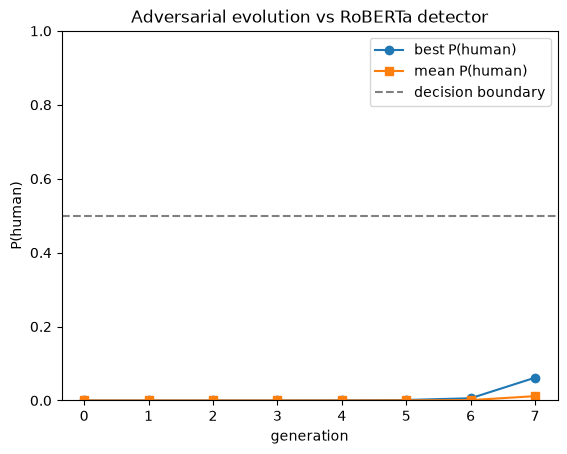

best P(human) reached: 0.062
In sooth, thy erstwhile paragraph hath been transmuted into a veritable tour-de-force of grandiose eloquence, replete with an array of recondite and venerable vocables, calculated to evoke the rarefied atmospherics of a bygone era. Methinks, an alternative iteration, suffused with an even more extensive plethora of arcane and antiquated phraseology, would be felicitous. 

Thus, permit me to aver that they languish in a state of existential thraldom, fettered by an ineffable and crepuscular tenebrosity, that doth pervade the umbrageous hours, beset by the vicissitudes, mutabilities, and fortuitous contingencies of fate, which hath engendered a profound and abject despondency, replete with languor, lassitude, and anhedonia, that permeateth every facet of their quotidian existence, leaving them to ruminate on the prospect of ever extricating themselves from the onerous vassalage imposed upon them by the capricious and inconstant decrees of destiny, which, in i

In [ ]:
plt.plot(history["gen"], history["max"], marker="o", label="best P(human)")
plt.plot(history["gen"], history["mean"], marker="s", label="mean P(human)")
plt.axhline(0.5, ls="--", c="grey", label="decision boundary")
plt.xlabel("generation"); plt.ylabel("P(human)"); plt.ylim(0,1)
plt.legend(); plt.title("Adversarial evolution vs RoBERTa detector")
plt.savefig("output/task-4/results_ga.png", dpi=120); plt.show()
best = log.sort_values("fitness", ascending=False).iloc[0]
print("best P(human) reached:", round(best["fitness"],3))
print(best["text"])
print("\nHonest read: report this ceiling as-is. If it plateaus below 0.5 the detector is robust;")
print("if archaic-word mutations win, that adversarially confirms the era/register confound.")

## The personal test — run the SOP through the detector
Closer: does the detector think you wrote like a human? (From Task 3, the SOP scores P(human)=0.000 — AI-flagged for modern register.) Optionally evolve one SOP paragraph toward "human" and see what the GA changes.

In [14]:
sop = load_jsonl(Path("data/dataset")/"probe_sop.jsonl")
for r in sop[:3]:
    print(round(p_human(r["text"]), 3), "|", r["text"][:90], "...")

# Optional: evolve the SOP toward human and inspect what register the GA injects
client = make_client()
h2, l2 = evolve(client, [sop[0]["text"]]*5, generations=6)
print("SOP evolved best P(human):", round(l2["fitness"].max(),3))

0.0 | There are some labs you discover and think, “this is interesting.” And then there are a fe ...
0.0 | Over time, I have realized that this is the kind of researcher I want to become. I enjoy b ...
0.0 | A major reason for this excitement is Prof. Ponnurangam Kumaraguru. From everything I have ...
gen 0: max=0.000 mean=0.000
gen 1: max=0.000 mean=0.000
gen 2: max=0.000 mean=0.000
gen 3: max=0.002 mean=0.000
gen 4: max=0.058 mean=0.006
gen 5: max=0.100 mean=0.017
SOP evolved best P(human): 0.1
